## Data Quality & Observation Timeline

### Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [32]:
df = pd.read_csv("sylhet_aman_observations_2022_2024.csv")

### Basic Dataset Structure

In [33]:
print("\n--- DATASET STRUCTURE ---")

print("Number of observations:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())


--- DATASET STRUCTURE ---
Number of observations: 126
Number of columns: 13

Columns:
['system:index', 'clear_pct', 'clear_pixel_count', 'date', 'doy', 'month', 'ndvi_mean', 'ndvi_median', 'scene_cloud_pct', 'spacecraft', 'total_cropland_pixel_count', 'year', '.geo']


### Missing Values

In [34]:
print("--- MISSING VALUES ---")

print(df.isna().sum())

--- MISSING VALUES ---
system:index                   0
clear_pct                      0
clear_pixel_count              0
date                           0
doy                            0
month                          0
ndvi_mean                     58
ndvi_median                   58
scene_cloud_pct                0
spacecraft                     0
total_cropland_pixel_count     0
year                           0
.geo                           0
dtype: int64


### Convert Date

In [35]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')
# Sort chronology
df = (df.sort_values("date").reset_index(drop=True))


# Check whether any dates failed to convert
invalid_dates = df["date"].isna().sum()
print("\nNumber of invalid dates:", invalid_dates)


Number of invalid dates: 0


In [36]:
print("First observation:",
      df["date"].min())

print("Last observation:",
      df["date"].max())

First observation: 2022-06-05 00:00:00
Last observation: 2024-12-31 00:00:00


### Check Study Year

In [37]:
print("\n--- OBSERVATIONS BY YEAR ---")

print(
    df["year"]
    .value_counts()
    .sort_index()
)


--- OBSERVATIONS BY YEAR ---
year
2022    42
2023    40
2024    44
Name: count, dtype: int64


In [38]:

print("\n--- DUPLICATE CHECK ---")

print("Duplicate rows:", df.duplicated().sum())

print("Duplicate acquisition dates:", df["date"].duplicated().sum())


# Inspect duplicate dates, if any
duplicate_dates = df[df["date"].duplicated(keep=False)].sort_values("date")

if len(duplicate_dates) > 0:

    print("\nDuplicate-date records:")

    print(
        duplicate_dates[
            [
                "date",
                "spacecraft",
                "system:index",
                "clear_pct"
            ]
        ]
    )


--- DUPLICATE CHECK ---
Duplicate rows: 0
Duplicate acquisition dates: 1

Duplicate-date records:
          date   spacecraft                              system:index  \
120 2024-12-11  Sentinel-2A  2_20241211T043201_20241211T043156_T46RCN   
121 2024-12-11  Sentinel-2C  2_20241211T043221_20241211T043614_T46RCN   

     clear_pct  
120  72.903651  
121  34.409757  


As the spacecraft isnot same so, it is not the duplicate data. and we will not remove this.

### Check clear-percentage value and ndvi values

In [39]:
# Checking clear_pct
print("\n--- CLEAR PERCENTAGE CHECK ---")

print(df["clear_pct"].describe())


# Checking ndvi
print("\n--- NDVI CHECK ---")

print(df[["ndvi_mean", "ndvi_median"]].describe())

print("Missing NDVI mean:", df["ndvi_mean"].isna().sum())

print("Missing NDVI median:", df["ndvi_median"].isna().sum())


--- CLEAR PERCENTAGE CHECK ---
count    126.000000
mean      35.751097
std       43.714883
min        0.000000
25%        0.000000
50%        0.248896
75%       89.149839
max       99.996706
Name: clear_pct, dtype: float64

--- NDVI CHECK ---
       ndvi_mean  ndvi_median
count  68.000000    68.000000
mean    0.470432     0.490773
std     0.202732     0.229174
min    -0.030819    -0.042957
25%     0.352187     0.316364
50%     0.466942     0.492227
75%     0.652962     0.689948
max     0.781429     0.863330
Missing NDVI mean: 58
Missing NDVI median: 58


### Actual Acquisition Interval

In [40]:
df["acquisition_interval_days"] = (
    df["date"].diff().dt.days
)


print("\n--- ACQUISITION INTERVAL ---")

print(
    df["acquisition_interval_days"]
    .dropna()
    .describe()
)


--- ACQUISITION INTERVAL ---
count    125.000000
mean       7.520000
std       19.537227
min        0.000000
25%        5.000000
50%        5.000000
75%        5.000000
max      160.000000
Name: acquisition_interval_days, dtype: float64


In [44]:
print("\n--- LARGEST ACQUISITION INTERVALS ---")

print(
    df[
        [
            "date",
            "acquisition_interval_days",
            "spacecraft",
            "clear_pct"
        ]
    ]
    .sort_values(
        "acquisition_interval_days",
        ascending=False
    )
    .head(7)
)


--- LARGEST ACQUISITION INTERVALS ---
         date  acquisition_interval_days   spacecraft  clear_pct
42 2023-06-05                      160.0  Sentinel-2B  97.283151
82 2024-06-04                      160.0  Sentinel-2A   0.000000
76 2023-12-02                       10.0  Sentinel-2B  85.670696
73 2023-11-12                       10.0  Sentinel-2B  99.996706
2  2022-06-15                        5.0  Sentinel-2A   0.000000
6  2022-07-05                        5.0  Sentinel-2A  85.249261
7  2022-07-10                        5.0  Sentinel-2B  81.447504


### Observation by year and month

In [46]:
month_counts = (
    df
    .groupby(["year", "month"])
    .size()
    .reset_index(
        name="acquisition_opportunities"
    )
)

print("\n--- ACQUISITION OPPORTUNITIES BY MONTH ---")

print(month_counts)


--- ACQUISITION OPPORTUNITIES BY MONTH ---
    year  month  acquisition_opportunities
0   2022      6                          6
1   2022      7                          6
2   2022      8                          6
3   2022      9                          6
4   2022     10                          6
5   2022     11                          6
6   2022     12                          6
7   2023      6                          6
8   2023      7                          6
9   2023      8                          6
10  2023      9                          6
11  2023     10                          6
12  2023     11                          4
13  2023     12                          6
14  2024      6                          6
15  2024      7                          6
16  2024      8                          6
17  2024      9                          6
18  2024     10                          6
19  2024     11                          6
20  2024     12                          8


### Basic Clear-Percentage Timeline

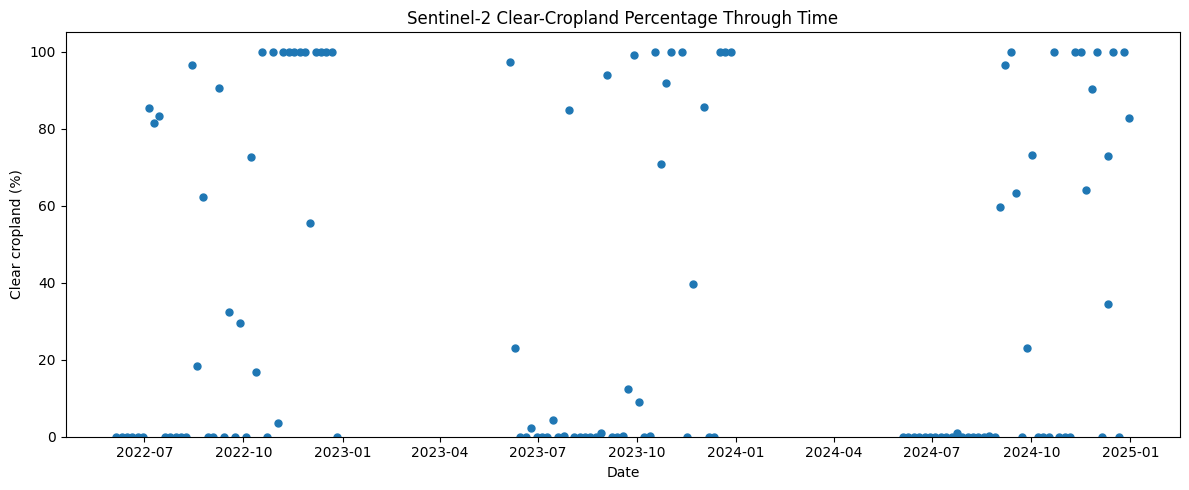

In [48]:
plt.figure(figsize=(12, 5))

plt.scatter(
    df["date"],
    df["clear_pct"],
    s=25
)

plt.xlabel("Date")
plt.ylabel("Clear cropland (%)")

plt.title(
    "Sentinel-2 Clear-Cropland Percentage Through Time"
)

plt.ylim(0, 105)

plt.tight_layout()
plt.show()

### Summary

In [53]:
print("\n============================================================")
print("Summary")
print("============================================================")

print(
    "Total acquisition opportunities:",
    len(df)
)

print(
    "Study period:",
    df["date"].min().date(),
    "to",
    df["date"].max().date()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)


print(
    "Missing clear_pct:",
    df["clear_pct"].isna().sum()
)

print(
    "Missing NDVI median:",
    df["ndvi_median"].isna().sum()
)

intervals = df["acquisition_interval_days"].dropna()
print("Maximum interval:",
      intervals.max(), "days")


Summary
Total acquisition opportunities: 126
Study period: 2022-06-05 to 2024-12-31
Duplicate rows: 0
Missing clear_pct: 0
Missing NDVI median: 58
Maximum interval: 160.0 days
